In [5]:
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path

CURR_PATH = Path.cwd()
DATAPATH = Path.cwd().joinpath("intensity.parquet")

print(CURR_PATH)
table = pq.read_table(DATAPATH)
df = table.to_pandas()


/Users/sebastianodutola/Projects/Carbon_Intensity


In [276]:
df.rename(columns={"from":"start", "to":"end"}, inplace=True)
df['forecast'] = [row['forecast'] for row in df['intensity']]
df.drop('intensity', axis=1)

,start,end,forecast
0,2026-02-25T12:00Z,2026-02-25T12:30Z,116
1,2026-02-25T12:30Z,2026-02-25T13:00Z,116
2,2026-02-25T13:00Z,2026-02-25T13:30Z,115
3,2026-02-25T13:30Z,2026-02-25T14:00Z,115
4,2026-02-25T14:00Z,2026-02-25T14:30Z,113
...,...,...,...
91,2026-02-27T09:30Z,2026-02-27T10:00Z,148
92,2026-02-27T10:00Z,2026-02-27T10:30Z,146
93,2026-02-27T10:30Z,2026-02-27T11:00Z,128
94,2026-02-27T11:00Z,2026-02-27T11:30Z,118


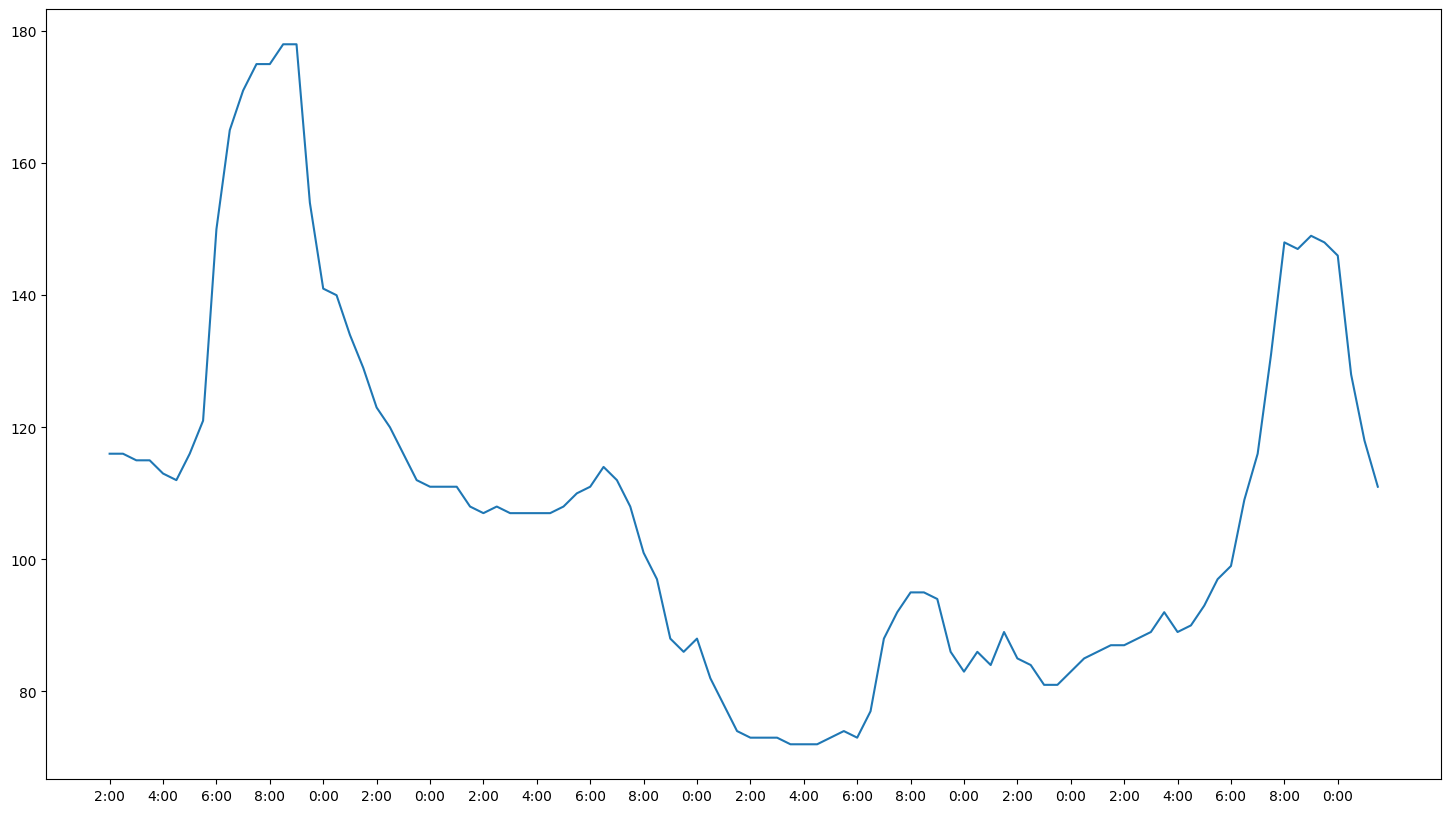

In [277]:
import matplotlib.pyplot as plt
def transform(iso_time: str):
    return iso_time[12:-1]

plt.figure(figsize=(18,10))
plt.plot(df['start'], df['forecast'])
plt.xticks(df['start'][::4], df['start'].apply(transform)[::4]);


In [278]:
from datetime import datetime
from datetime import timedelta, timezone

dt = datetime(2001,9,11, tzinfo=timezone.utc)
dt2 = datetime(2001,10,11, tzinfo=timezone.utc)
ar = [dt2, dt]
sorted(ar)

[datetime.datetime(2001, 9, 11, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2001, 10, 11, 0, 0, tzinfo=datetime.timezone.utc)]

In [279]:
s_forecast = df.copy()
for f in s_forecast.itertuples():
    if f.forecast == 140:
        print(f)
        s_forecast.drop(index=f.Index, inplace=True)
print(s_forecast)

Pandas(Index=17, start='2026-02-25T20:30Z', end='2026-02-25T21:00Z', intensity={'actual': None, 'forecast': 140, 'index': 'moderate'}, forecast=140)
                start                end  \
0   2026-02-25T12:00Z  2026-02-25T12:30Z   
1   2026-02-25T12:30Z  2026-02-25T13:00Z   
2   2026-02-25T13:00Z  2026-02-25T13:30Z   
3   2026-02-25T13:30Z  2026-02-25T14:00Z   
4   2026-02-25T14:00Z  2026-02-25T14:30Z   
..                ...                ...   
91  2026-02-27T09:30Z  2026-02-27T10:00Z   
92  2026-02-27T10:00Z  2026-02-27T10:30Z   
93  2026-02-27T10:30Z  2026-02-27T11:00Z   
94  2026-02-27T11:00Z  2026-02-27T11:30Z   
95  2026-02-27T11:30Z  2026-02-27T12:00Z   

                                            intensity  forecast  
0   {'actual': None, 'forecast': 116, 'index': 'mo...       116  
1   {'actual': None, 'forecast': 116, 'index': 'mo...       116  
2   {'actual': None, 'forecast': 115, 'index': 'mo...       115  
3   {'actual': None, 'forecast': 115, 'index': 'mo...     

In [280]:
import pandas as pd
class Load: 
    def __init__(self, capacity: int, charge_power: int, usage: list[dict]):
        self.capacity = capacity 
        self.charge_power = charge_power 
        self.usage = usage

def optimal_charge(load: Load, forecast: pd.DataFrame):
    # remove times we can't charge
    usage = sorted(load.usage, key=lambda u: u["start"])
    usage_times = [(u["start"], u["end"]) for u in usage]
    
    if usage_times:
        t = usage_times.pop(0)
    s_forecast = forecast.copy()
    invalid_indices = []

    for f in s_forecast.itertuples(): 
        if f.start > t[1]:
            if usage_times: 
                t = usage_times.pop(0)
            else: 
                break
        if f.end > t[0] - timedelta(minutes=30):
            invalid_indices.append(f.Index)
    
    s_forecast.drop(index=invalid_indices, inplace=True)

    # find optimal charging O(number of discharge times * forecast length)  
    s_forecast.sort_values(by="forecast", inplace=True)
    charge = 0 
    carbon = 0 
    charging_times = set()
    for discharge in usage:
        E = (discharge["end"] - discharge["start"]).total_seconds() * discharge["power"]
        seen_indices = []
        for f in s_forecast.itertuples():
            if f.start < discharge["start"]:
                delta_charge = 1800 * load.charge_power
                charge += delta_charge 
                carbon += delta_charge * f.forecast
                seen_indices.append(f.Index)
                charging_times.add(f.start)
                if charge > E:
                    break
        charge -= E
        if charge < 0:
            print(f"insufficient time to charge load for discharge starting at {discharge['start']}")
            charge = 0
        s_forecast.drop(index=seen_indices, inplace=True)
    if charge < 0:
        print("insufficient time to charge load...")
    return sorted(list(charging_times)), carbon

def naive_charge(load: Load, forecast: list[tuple]):
    usage = sorted(load.usage, key=lambda u: u["start"])
    usage_times = [(u["start"], u["end"]) for u in usage]
    if usage_times:
        t = usage_times.pop(0)
    s_forecast = forecast.copy()
    invalid_indices = []

    for f in s_forecast.itertuples(): 
        if f.start > t[1]:
            if usage_times: 
                t = usage_times.pop(0)
            else: 
                break
        if f.end > t[0] - timedelta(minutes=30):
            invalid_indices.append(f.Index)
    
    s_forecast.drop(index=invalid_indices, inplace=True)
    charge = 0
    carbon = 0 
    charging_times = []
    
    if usage:
        l = usage.pop(0)
        E = (l["end"] - l["start"]).total_seconds() * l["power"]

    for f in s_forecast.itertuples():
        if f.start > l["start"]:
            if charge-E < 0:
                print(f"naive: insufficient time to charge load for discharge starting at {l['start']}")
            charge = max(charge - E, 0)
            if usage:
                l = usage.pop(0)
            else:
                break
        if charge < load.capacity:
            delta_charge = 1800 * load.charge_power
            charge += delta_charge 
            carbon += delta_charge * f.forecast
            charging_times.append(f.start)
    return charging_times, carbon

In [281]:
import numpy as np
from datetime import timezone
# synthetic example 
dt = datetime(2000,1,1,5, tzinfo=timezone.utc)
dt_dash = datetime(2000, 1,1,10,tzinfo=timezone.utc)
dt1 = datetime(2000, 1, 1, 18,tzinfo=timezone.utc)
dt2 = datetime(2000, 1, 1, 18, 30,tzinfo=timezone.utc)
p = 1000
forecast = pd.DataFrame([(datetime(2000,1,1,m//60, m%60, tzinfo=timezone.utc), np.sin(m/5)**2**2) for m in range(0,1440,30)])
forecast.rename(columns={0: "start", 1: "forecast"}, inplace=True)
forecast["end"] = forecast["start"] + timedelta(minutes=30)

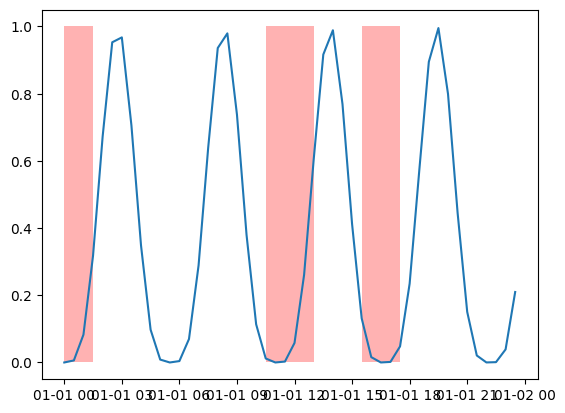

In [282]:
load = Load(100_000, 10, [{"start": dt, "end":dt_dash, "power": 1},{"start": dt1, "end": dt2, "power": 100}])
times, _ = optimal_charge(load, forecast)
plt.plot(forecast["start"],forecast["forecast"])
y = [0,1]
for time in times:
    dt_start = time
    dt_end = dt_start + timedelta(minutes=30)
    plt.fill_betweenx(y, dt_start, dt_end, color="red", alpha=0.3, linewidth=0);

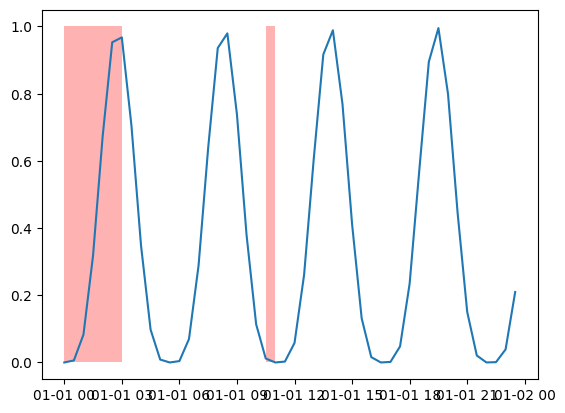

In [283]:
times, _ = naive_charge(load, forecast)
plt.plot(forecast["start"],forecast["forecast"])
y = [0,1]
for time in times:
    dt_start = time
    dt_end = dt_start + timedelta(minutes=30)
    plt.fill_betweenx(y, dt_start, dt_end, color="red", alpha=0.3, linewidth=0);

In [284]:
df["start"] = df["start"].apply(datetime.fromisoformat)
df["end"] = df["end"].apply(datetime.fromisoformat)

optimal carbon cost: 51048000 
 naive carbon cost: 59148000 
 percentage: 86.30553864881315%


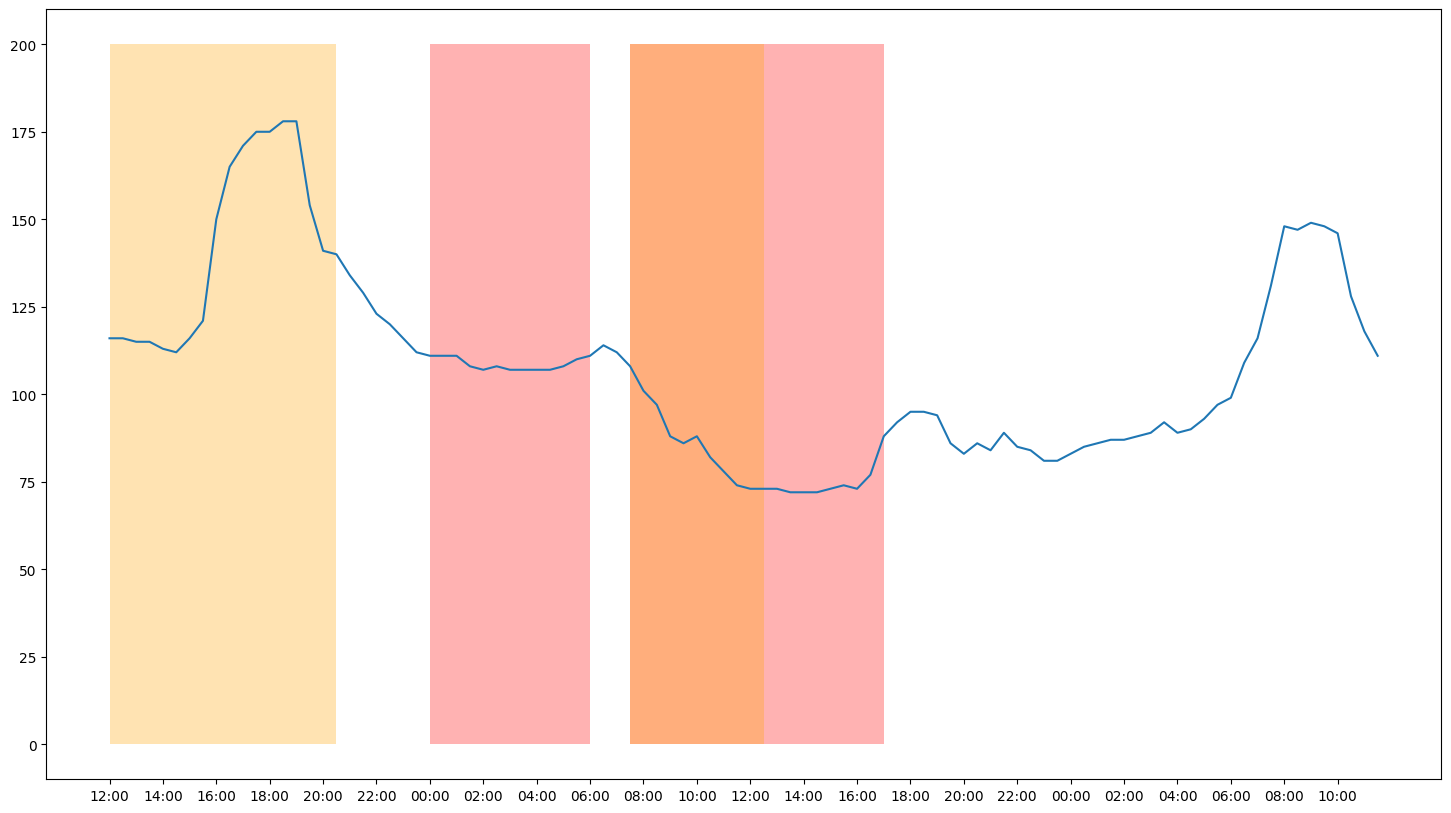

In [285]:
from datetime import date, time, timezone
# synthetic example with real carbon data
times = [((6,30),(7,0)), ((17,30),(18,30))]
power = 100
dt_tomorrow = date.today() + timedelta(days=1)
usage = []
for i in times:
    t1 = time(hour=i[0][0], minute=i[0][1] )
    t2 = time(hour=i[1][0], minute=i[1][1] )
    dt_start = datetime.combine(dt_tomorrow, t1, tzinfo=timezone.utc)
    dt_end = datetime.combine(dt_tomorrow, t2, tzinfo=timezone.utc)
    usage.append({"start":dt_start,"end":dt_end,"power":power})


load = Load(300_000, 10, usage)

optimal_times, optimal_carbon = optimal_charge(load, df)
naive_times, naive_carbon = naive_charge(load, df)
plt.figure(figsize=(18,10))
plt.plot(df["start"],df["forecast"])
plt.xticks(df["start"][::4], [dt.time().isoformat("minutes") for dt in df["start"]][::4])
y = [0,200]
for t in optimal_times:
    dt_start = t
    dt_end = dt_start + timedelta(minutes=30)
    plt.fill_betweenx(y, dt_start, dt_end, color="red", alpha=0.3, linewidth=0);

for t in naive_times:
    dt_start = t
    dt_end = dt_start + timedelta(minutes=30)
    plt.fill_betweenx(y, dt_start, dt_end, color="orange", alpha=0.3, linewidth=0)

print(f"optimal carbon cost: {optimal_carbon} \n naive carbon cost: {naive_carbon} \n percentage: {optimal_carbon/naive_carbon * 100}%")


In [1]:
from datetime import timedelta

print( timedelta(hours=0.5))

0:30:00
